# Generations vs Best Cumulative Average Reward From **World model(M)** & **VAE**(V) Model **Training**

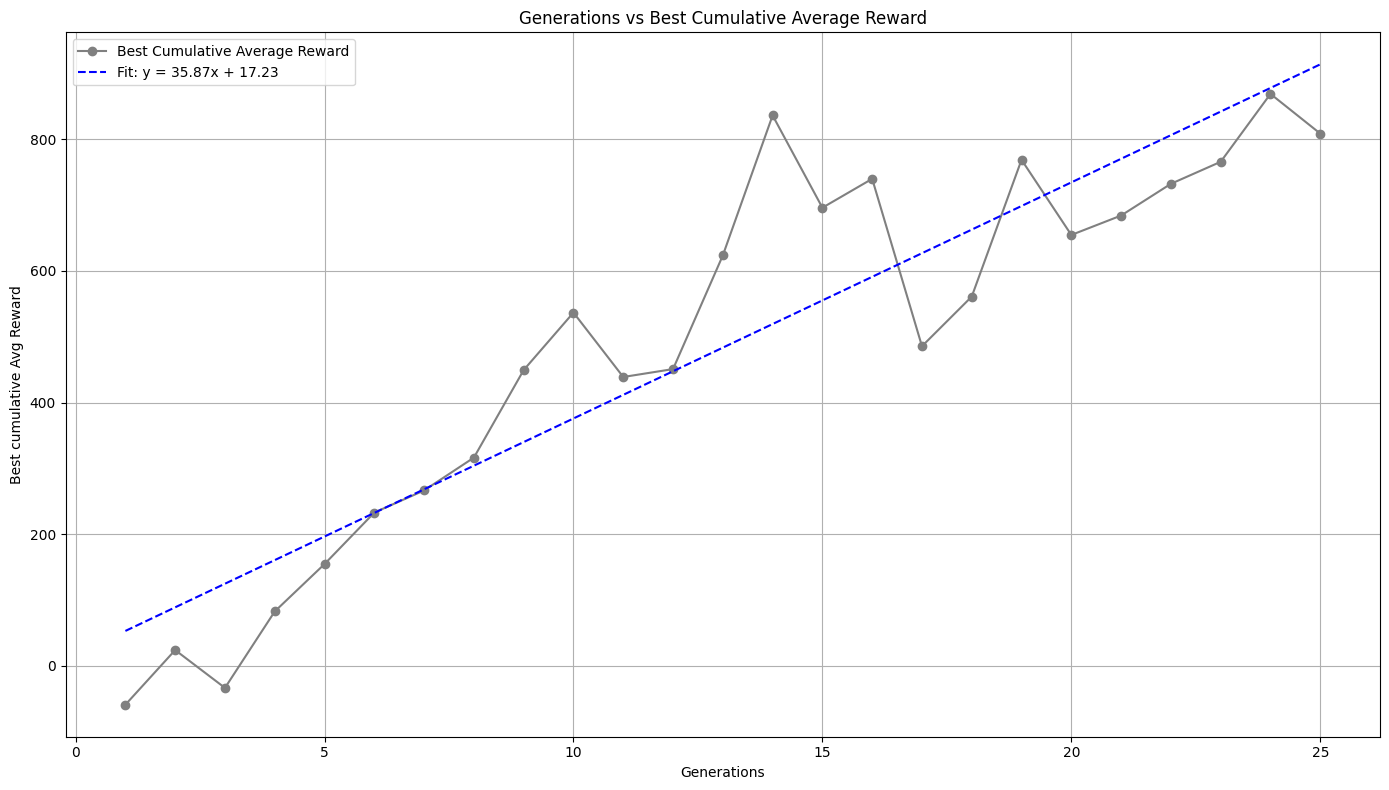

In [1]:

import matplotlib.pyplot as plt
import numpy as np

generations = np.arange(1, 26)



rewards = np.array([-58.99, 24.03, -33.45, 82.72, 154.72, 232.96, 266.54, 316.43,
                    449.47, 536.78, 438.93, 450.93, 623.62, 836.34, 696.11, 740.01,
                    485.67, 561.09, 768.90, 654.73, 684.22, 732.43, 765.88, 869.04, 808.76])


coeffs = np.polyfit(generations, rewards, 1)
fit_line = np.poly1d(coeffs)

plt.figure(figsize=(14, 8))
plt.plot(generations, rewards, 'o-', color='gray', label='Best Cumulative Average Reward')
plt.plot(generations, fit_line(generations), 'b--',
         label=f'Fit: y = {coeffs[0]:.2f}x + {coeffs[1]:.2f}')
plt.xlabel('Generations')
plt.ylabel('Best cumulative Avg Reward')
plt.title('Generations vs Best Cumulative Average Reward')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# **Training the controler only using V Model(DQN algo)**

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from google.colab import drive
import gymnasium as gym
import cv2
import matplotlib.pyplot as plt

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:

import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, latent_dim=512):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim  # store it

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(256*4*4, latent_dim)
        self.fc_logvar = nn.Linear(256*4*4, latent_dim)

        self.fc_dec = nn.Linear(latent_dim, 256*4*4)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        x = self.fc_dec(z)
        x = x.view(-1, 256, 4, 4)
        x = self.decoder(x)
        return x

    def forward(self, x):
        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)

        # Returns reconstructed image + latent parameters
        return x_recon, mu, logvar



In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

latent_dim = 512
vae = VAE(latent_dim=latent_dim)
vae.load_state_dict(torch.load("vae_carracing.pth", map_location=device))
vae.to(device)
vae.eval()

VAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
  )
  (fc_mu): Linear(in_features=4096, out_features=512, bias=True)
  (fc_logvar): Linear(in_features=4096, out_features=512, bias=True)
  (fc_dec): Linear(in_features=512, out_features=4096, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), paddi

In [6]:
ACTIONS = [

    # Straight driving
    np.array([0.0, 1.0, 0.0]),
    np.array([0.0, 0.6, 0.0]),
    np.array([0.0, 0.3, 0.0]),

    # Gentle steering (fine control)
    np.array([-0.1, 0.5, 0.0]),
    np.array([0.1, 0.5, 0.0]),

    # Medium turns
    np.array([-0.4, 0.8, 0.0]),
    np.array([0.4, 0.8, 0.0]),

    # Sharp turns
    np.array([-0.8, 0.4, 0.0]),
    np.array([0.8, 0.4, 0.0]),

    # Slow recovery turns
    np.array([-0.5, 0.2, 0.0]),
    np.array([0.5, 0.2, 0.0]),

    # Brake only
    np.array([0.0, 0.0, 0.6]),
    np.array([0.0, 0.0, 0.9]),

    # Turn + brake (very important for curves)
    np.array([-0.6, 0.0, 0.6]),
    np.array([0.6, 0.0, 0.6]),

    # Smooth turn + light brake
    np.array([-0.4, 0.2, 0.4]),
    np.array([0.4, 0.2, 0.4]),

    #  No action
    np.array([0.0, 0.0, 0.0]),
]

num_actions = len(ACTIONS)
num_actions


18

In [31]:
def encode_obs(obs, size=(64,64)):
    obs = cv2.resize(obs, size, interpolation=cv2.INTER_AREA)
    obs = torch.tensor(obs).float().permute(2,0,1)/255.0
    obs = obs.unsqueeze(0).to(device)

    with torch.no_grad():
        mu, logvar = vae.encode(obs)
        z = mu.view(mu.size(0), -1)

    return z.squeeze(0)

In [38]:

class DQN(nn.Module):
    def __init__(self, input_dim=latent_dim, output_dim=num_actions):
        super(DQN, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, output_dim)
        )
    def forward(self, x):
        return self.fc(x)  #Output: Q-values for each action


In [39]:

q_main = DQN(input_dim=latent_dim, output_dim=num_actions).to(device)
q_target = DQN(input_dim=latent_dim, output_dim=num_actions).to(device)
q_target.load_state_dict(q_main.state_dict())

optimizer = optim.Adam(q_main.parameters(), lr=1e-3)

In [40]:
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = []
        self.capacity = capacity

    def push(self, state, action, reward, next_state, done):
        if len(self.buffer) >= self.capacity:
            self.buffer.pop(0)
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        states = torch.stack(states).float()
        actions = torch.tensor(actions).long()
        rewards = torch.tensor(rewards).float()
        next_states = torch.stack(next_states).float()
        dones = torch.tensor(dones).float()
        return states, actions, rewards, next_states, dones


buffer = ReplayBuffer(capacity=50000)


# Training **Loop**

In [41]:
env = gym.make("CarRacing-v3")

dqn = DQN(input_dim=512, output_dim=num_actions).to(device)
target_dqn = DQN(input_dim=512, output_dim=num_actions).to(device)
target_dqn.load_state_dict(dqn.state_dict())

optimizer = torch.optim.Adam(dqn.parameters(), lr=1e-4)
buffer = ReplayBuffer()

gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.05


In [45]:
import torch
import torch.nn.functional as F
import random
import numpy as np

num_episodes = 400
max_steps = 1000
batch_size = 64

episode_rewards = []

for episode in range(num_episodes):
    obs, _ = env.reset()
    state = encode_obs(obs)
    total_reward = 0

    for t in range(max_steps):
        if random.random() < epsilon:
            action_idx = random.randint(0, len(ACTIONS) - 1)
        else:
            with torch.no_grad():
                q_values = dqn(state.unsqueeze(0))
                action_idx = torch.argmax(q_values, dim=1).item()

        action = ACTIONS[action_idx]
        next_obs, reward, done, truncated, _ = env.step(action)
        next_state = encode_obs(next_obs)
        buffer.push(state, action_idx, reward, next_state, done)
        state = next_state
        total_reward += reward

        if len(buffer.buffer) > 1000:
            states, actions, rewards, next_states, dones = buffer.sample(batch_size)
            states = states.to(device)
            next_states = next_states.to(device)
            actions = actions.to(device)
            rewards = rewards.to(device)
            dones = dones.to(device)
            q_values = dqn(states).gather(1, actions.unsqueeze(1)).squeeze()
            with torch.no_grad():
                next_q = target_dqn(next_states).max(1)[0]
                target = rewards + gamma * next_q * (1 - dones)
            loss = F.mse_loss(q_values, target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if done or truncated:
            break

    episode_rewards.append(total_reward)

    if episode % 10 == 0:
        target_dqn.load_state_dict(dqn.state_dict())

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    print(f"Episode: {episode}, Reward: {total_reward:.2f}, Epsilon: {epsilon:.3f}")

env.close()

torch.save(dqn.state_dict(), "/content/drive/MyDrive/dqn_policy_car_racing_V.pth")
print("Learned policy saved to /content/drive/MyDrive/dqn_policy_car_racing_V.pth")

np.save("/content/drive/MyDrive/episode_rewards.npy", np.array(episode_rewards))
print("Episode rewards saved to /content/drive/MyDrive/episode_rewards.npy")

Episode: 0, Reward: -32.48, Epsilon: 0.985
Episode: 1, Reward: -24.66, Epsilon: 0.980
Episode: 2, Reward: -46.37, Epsilon: 0.975
Episode: 3, Reward: -34.93, Epsilon: 0.970
Episode: 4, Reward: 17.22, Epsilon: 0.966
Episode: 5, Reward: -15.19, Epsilon: 0.961
Episode: 6, Reward: -27.84, Epsilon: 0.956
Episode: 7, Reward: -25.47, Epsilon: 0.951
Episode: 8, Reward: -31.37, Epsilon: 0.946
Episode: 9, Reward: -30.56, Epsilon: 0.942
Episode: 10, Reward: -35.28, Epsilon: 0.937
Episode: 11, Reward: -35.58, Epsilon: 0.932
Episode: 12, Reward: -20.96, Epsilon: 0.928
Episode: 13, Reward: -40.81, Epsilon: 0.923
Episode: 14, Reward: -37.89, Epsilon: 0.918
Episode: 15, Reward: 6.71, Epsilon: 0.914
Episode: 16, Reward: -33.12, Epsilon: 0.909
Episode: 17, Reward: 5.63, Epsilon: 0.905
Episode: 18, Reward: -26.57, Epsilon: 0.900
Episode: 19, Reward: -29.33, Epsilon: 0.896
Episode: 20, Reward: -22.22, Epsilon: 0.891
Episode: 21, Reward: -22.30, Epsilon: 0.887
Episode: 22, Reward: -23.08, Epsilon: 0.882
Epi

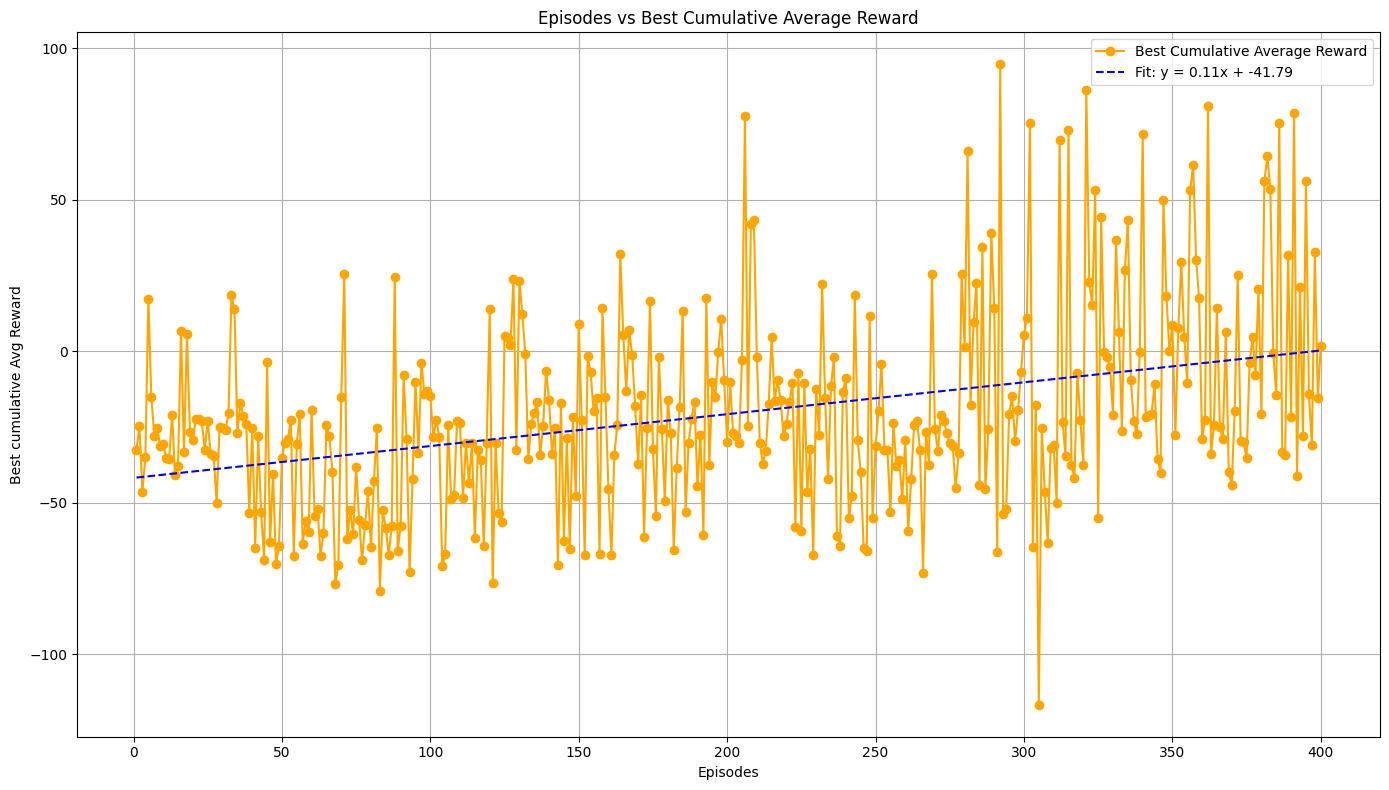

In [48]:
import matplotlib.pyplot as plt
import numpy as np

rewards = np.load("/content/drive/MyDrive/episode_rewards.npy")
episodes = np.arange(1, len(rewards) + 1)

coeffs = np.polyfit(episodes, rewards, 1)
fit_line = np.poly1d(coeffs)

plt.figure(figsize=(14, 8))
plt.plot(episodes, rewards, 'o-', color='orange', label='Best Cumulative Average Reward')
plt.plot(episodes, fit_line(episodes), 'b--',
         label=f'Fit: y = {coeffs[0]:.2f}x + {coeffs[1]:.2f}')
plt.xlabel('Episodes')
plt.ylabel('Best cumulative Avg Reward')
plt.title('Episodes vs Best Cumulative Average Reward')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
# !pip install gymnasium
# !pip install swig
# !pip install gymnasium[box2d]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 10.2 MB/s eta 0:00:00
